In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
X_scaled = pd.read_csv('data/X_scaled.csv')
X_pca_2d = pd.read_csv('data/X_pca_2d.csv')
exam_scores = pd.read_csv('data/exam_scores.csv').squeeze()
df_encoded = pd.read_csv('data/student_preprocessed.csv')

print(f"X_scaled shape: {X_scaled.shape}")
print(f"X_pca_2d shape: {X_pca_2d.shape}")
print("Data loaded")

X_scaled shape: (6607, 21)
X_pca_2d shape: (6607, 2)
Data loaded


k=2 | BIC: 175205.9 | AIC: 171774.0 | Silhouette: 0.0772 | DB: 3.3381 | CH: 547.5
k=3 | BIC: 98192.1 | AIC: 93040.8 | Silhouette: 0.0828 | DB: 3.0195 | CH: 433.1
k=4 | BIC: 48550.3 | AIC: 41679.7 | Silhouette: 0.1086 | DB: 2.6316 | CH: 469.0
k=5 | BIC: -23892.2 | AIC: -32482.2 | Silhouette: 0.1102 | DB: 2.4570 | CH: 439.7
k=6 | BIC: -22165.5 | AIC: -32474.9 | Silhouette: 0.0804 | DB: 3.0343 | CH: 377.2
k=7 | BIC: -34357.6 | AIC: -46386.3 | Silhouette: 0.0599 | DB: 3.4405 | CH: 337.1
k=8 | BIC: -48240.4 | AIC: -61988.5 | Silhouette: 0.0692 | DB: 3.1446 | CH: 286.6


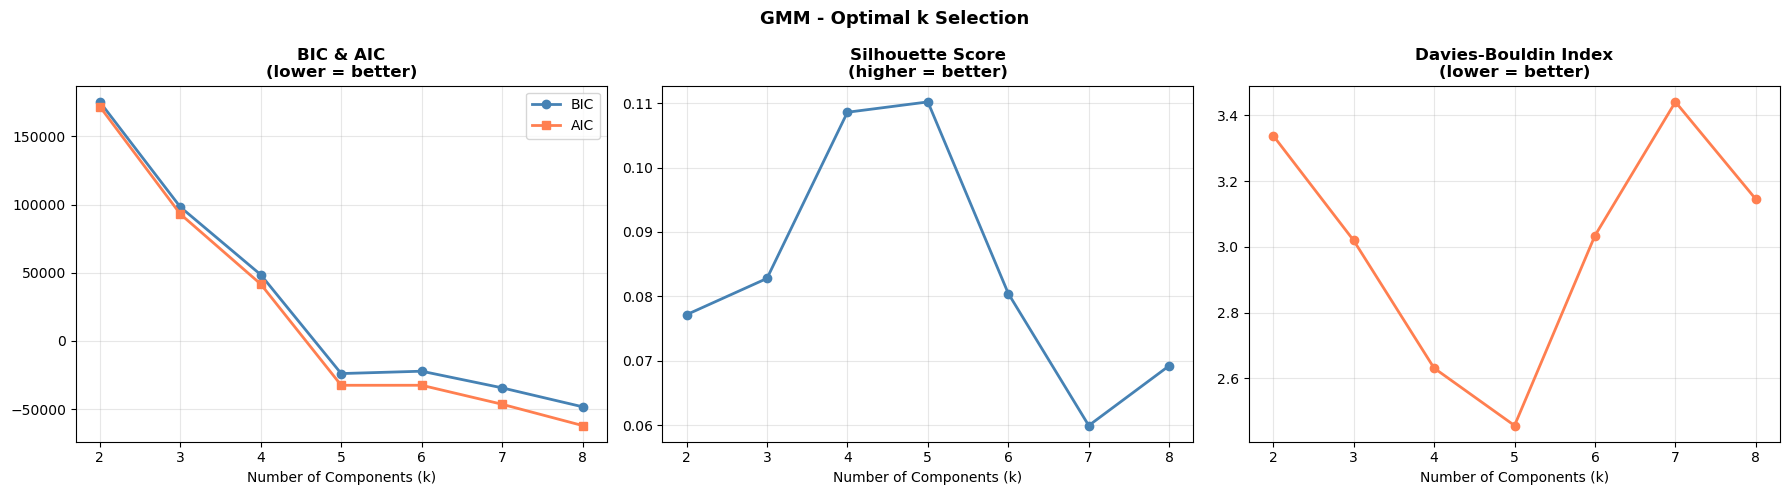


Elbow/lowest point in BIC and AIC
Confirm with peak in Silhouette and lowest Davies-Bouldin


In [3]:
# GMM uses BIC and AIC to select optimal k
# BIC = Bayesian info criterion (lower = better, penalises complexity)
# AIC = Akaike info criterion (lower = better, less penalty)
# Silhouette included for consistency w other models

k_range = range(2, 9)
bic_scores = []
aic_scores = []
silhouette_scores = []
db_scores = []
ch_scores = []

X_array = np.array(X_scaled)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', 
                          n_init=10, random_state=42)
    gmm.fit(X_array)
    labels = gmm.predict(X_array)
    
    bic = gmm.bic(X_array)
    aic = gmm.aic(X_array)
    sil = silhouette_score(X_array, labels, sample_size=2000, random_state=42)
    db  = davies_bouldin_score(X_array, labels)
    ch  = calinski_harabasz_score(X_array, labels)
    
    bic_scores.append(bic)
    aic_scores.append(aic)
    silhouette_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    
    print(f"k={k} | BIC: {bic:.1f} | AIC: {aic:.1f} | "
          f"Silhouette: {sil:.4f} | DB: {db:.4f} | CH: {ch:.1f}")

# Plot all metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, bic_scores, marker='o', color='steelblue', 
             linewidth=2, label='BIC')
axes[0].plot(k_range, aic_scores, marker='s', color='coral', 
             linewidth=2, label='AIC')
axes[0].set_title('BIC & AIC\n(lower = better)', fontweight='bold')
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_xticks(list(k_range))
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Silhouette Score\n(higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

axes[2].plot(k_range, db_scores, marker='o', color='coral', linewidth=2)
axes[2].set_title('Davies-Bouldin Index\n(lower = better)', fontweight='bold')
axes[2].set_xlabel('Number of Components (k)')
axes[2].set_xticks(list(k_range))
axes[2].grid(alpha=0.3)

plt.suptitle('GMM - Optimal k Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/gmm_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nElbow/lowest point in BIC and AIC")
print("Confirm with peak in Silhouette and lowest Davies-Bouldin")

In [4]:
# GMM has 4 covariance types 
# full = each cluster has its own general covariance matrix (most flexible)
# tied = all clusters share the same covariance matrix
# diag = diagonal covariance (assumes feature independence)
# spherical = single variance per cluster (similar to K-Means)

cov_types = ['full', 'tied', 'diag', 'spherical']
cov_results = []

K_FOR_COV = 5 

for cov in cov_types:
    try:
        gmm = GaussianMixture(n_components=K_FOR_COV, covariance_type=cov,
                              n_init=10, random_state=42)
        gmm.fit(X_array)
        labels = gmm.predict(X_array)
        
        unique = len(np.unique(labels))
        if unique < 2:
            raise ValueError(f"Only {unique} component formed")
        
        sil = silhouette_score(X_array, labels, sample_size=2000, random_state=42)
        db  = davies_bouldin_score(X_array, labels)
        bic = gmm.bic(X_array)
        
        # Check distribution
        dist = pd.Series(labels).value_counts()
        imbalance = dist.max() / dist.min()
        
        cov_results.append({
            'Covariance Type': cov,
            'Silhouette Score': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'BIC': round(bic, 1),
            'Imbalance Ratio': round(imbalance, 1),
            'Note': 'Valid'
        })
        print(f"'{cov}': Silhouette={sil:.4f}, DB={db:.4f}, "
              f"BIC={bic:.1f}, Imbalance={imbalance:.1f}x")
        
    except Exception as e:
        print(f"'{cov}' failed: {e}")
        cov_results.append({
            'Covariance Type': cov,
            'Silhouette Score': 'N/A',
            'Davies-Bouldin': 'N/A',
            'BIC': 'N/A',
            'Imbalance Ratio': 'N/A',
            'Note': f'Failed: {e}'
        })

cov_df = pd.DataFrame(cov_results)
print("\nCOVARIANCE TYPE COMPARISON")
print(cov_df.to_string(index=False))
cov_df.to_csv('data/gmm_covariance_comparison.csv', index=False)
print("\nSaved")

'full': Silhouette=0.1102, DB=2.4570, BIC=-23892.2, Imbalance=4.4x
'tied': Silhouette=0.0771, DB=3.4809, BIC=112915.3, Imbalance=2.4x
'diag': Silhouette=0.1102, DB=2.4570, BIC=-16397.1, Imbalance=4.4x
'spherical': Silhouette=0.1102, DB=2.4570, BIC=380711.0, Imbalance=4.4x

COVARIANCE TYPE COMPARISON
Covariance Type  Silhouette Score  Davies-Bouldin      BIC  Imbalance Ratio  Note
           full            0.1102          2.4570 -23892.2              4.4 Valid
           tied            0.0771          3.4809 112915.3              2.4 Valid
           diag            0.1102          2.4570 -16397.1              4.4 Valid
      spherical            0.1102          2.4570 380711.0              4.4 Valid

Saved


In [5]:
OPTIMAL_K = 5  
COV_TYPE = 'full'

gmm_final = GaussianMixture(n_components=OPTIMAL_K, covariance_type=COV_TYPE,
                             n_init=10, random_state=42)
gmm_final.fit(X_array)

# Hard cluster assignments
cluster_labels = gmm_final.predict(X_array)

# Soft assignments
probabilities = gmm_final.predict_proba(X_array)
prob_df = pd.DataFrame(probabilities, 
                       columns=[f'P(Cluster {i})' for i in range(OPTIMAL_K)])

print(f"Final GMM fitted: k={OPTIMAL_K}, covariance='{COV_TYPE}'")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print(f"\nSample soft probabilities (first 5 students):")
print(prob_df.head().round(3))

Final GMM fitted: k=5, covariance='full'

Cluster distribution:
0     499
1    2180
2     646
3    1138
4    2144
dtype: int64

Sample soft probabilities (first 5 students):
   P(Cluster 0)  P(Cluster 1)  P(Cluster 2)  P(Cluster 3)  P(Cluster 4)
0           0.0           1.0           0.0           0.0           0.0
1           0.0           0.0           0.0           1.0           0.0
2           0.0           0.0           0.0           0.0           1.0
3           0.0           0.0           0.0           1.0           0.0
4           0.0           0.0           0.0           0.0           1.0


In [6]:
dist = pd.Series(cluster_labels).value_counts().sort_index()
imbalance = dist.max() / dist.min()

print("CLUSTER DISTRIBUTION")
print(dist)
print(f"\nSmallest cluster: {dist.min()} students")
print(f"Largest cluster:  {dist.max()} students")
print(f"Imbalance ratio:  {imbalance:.1f}x")

if imbalance > 20:
    print("WARNING: High imbalance. adjust k OR covariance type")
else:
    print("Distribution is acceptable")

CLUSTER DISTRIBUTION
0     499
1    2180
2     646
3    1138
4    2144
dtype: int64

Smallest cluster: 499 students
Largest cluster:  2180 students
Imbalance ratio:  4.4x
Distribution is acceptable


In [7]:
sil_final = silhouette_score(X_array, cluster_labels, 
                              sample_size=2000, random_state=42)
db_final  = davies_bouldin_score(X_array, cluster_labels)
ch_final  = calinski_harabasz_score(X_array, cluster_labels)
bic_final = gmm_final.bic(X_array)
aic_final = gmm_final.aic(X_array)

print("FINAL GMM EVALUATION")
print(f"Number of components:     {OPTIMAL_K}")
print(f"Covariance type:          {COV_TYPE}")
print(f"Silhouette Score:         {sil_final:.4f}  (higher is better)")
print(f"Davies-Bouldin Index:     {db_final:.4f}  (lower is better)")
print(f"Calinski-Harabasz Score:  {ch_final:.1f}  (higher is better)")
print(f"BIC:                      {bic_final:.1f}  (lower is better)")
print(f"AIC:                      {aic_final:.1f}  (lower is better)")

metrics = {
    'Model': 'Gaussian Mixture Model',
    'Covariance Type': COV_TYPE,
    'n_clusters': OPTIMAL_K,
    'Silhouette Score': round(sil_final, 4),
    'Davies-Bouldin Index': round(db_final, 4),
    'Calinski-Harabasz Score': round(ch_final, 1),
    'BIC': round(bic_final, 1),
    'AIC': round(aic_final, 1)
}
pd.DataFrame([metrics]).to_csv('data/metrics_gmm.csv', index=False)
print("\nMetrics saved to data/metrics_gmm.csv")

FINAL GMM EVALUATION
Number of components:     5
Covariance type:          full
Silhouette Score:         0.1102  (higher is better)
Davies-Bouldin Index:     2.4570  (lower is better)
Calinski-Harabasz Score:  439.7  (higher is better)
BIC:                      -23892.2  (lower is better)
AIC:                      -32482.2  (lower is better)

Metrics saved to data/metrics_gmm.csv


SOFT ASSIGNMENT ANALYSIS
Students with >90% certainty in one cluster: 6607 (100.0%)
Students with <60% certainty (borderline):   0 (0.0%)


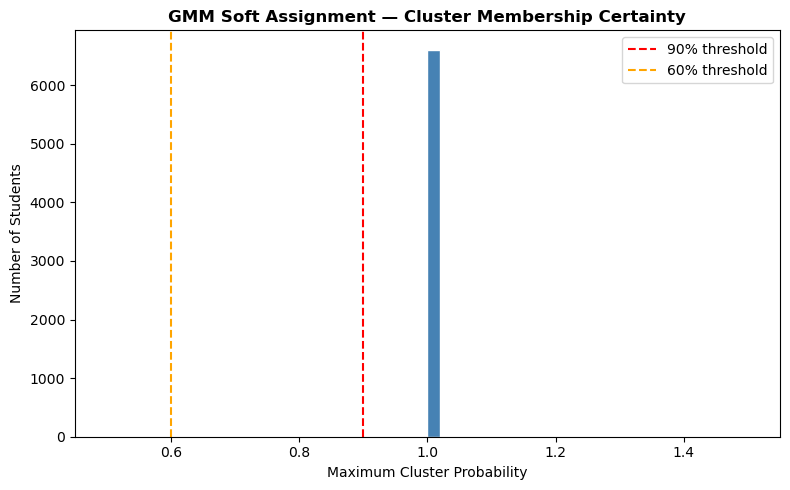

In [8]:
# Find students with uncertain membership (no cluster dominates)

max_prob = prob_df.max(axis=1)

print("SOFT ASSIGNMENT ANALYSIS")
print(f"Students with >90% certainty in one cluster: "
      f"{(max_prob > 0.9).sum()} "
      f"({(max_prob > 0.9).mean()*100:.1f}%)")
print(f"Students with <60% certainty (borderline):   "
      f"{(max_prob < 0.6).sum()} "
      f"({(max_prob < 0.6).mean()*100:.1f}%)")

# Plot certainty distribution
plt.figure(figsize=(8, 5))
plt.hist(max_prob, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0.9, color='red', linestyle='--', label='90% threshold')
plt.axvline(x=0.6, color='orange', linestyle='--', label='60% threshold')
plt.xlabel('Maximum Cluster Probability')
plt.ylabel('Number of Students')
plt.title('GMM Soft Assignment — Cluster Membership Certainty',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/gmm_soft_assignments.png', dpi=150, bbox_inches='tight')
plt.show()

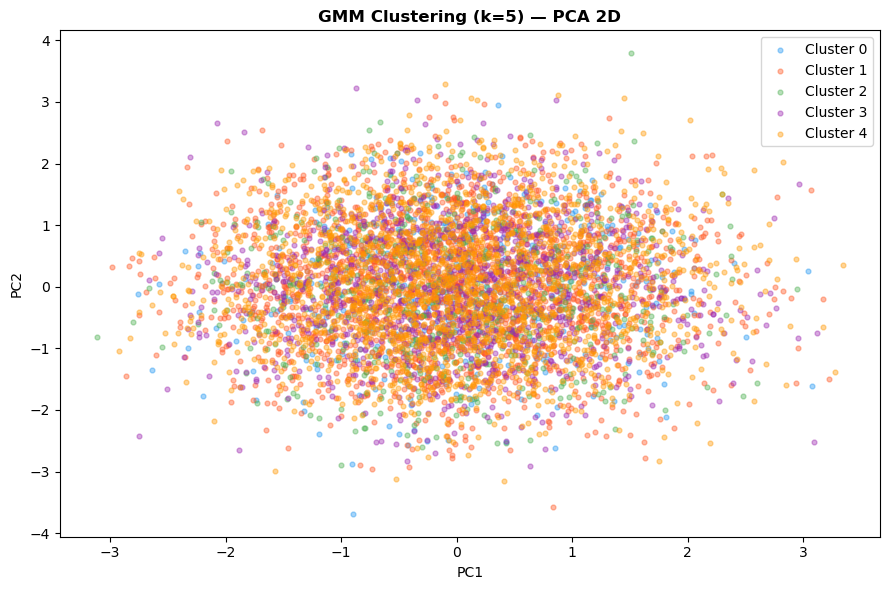

In [9]:
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

results_df = X_scaled.copy()
results_df['Cluster'] = cluster_labels
results_df['PC1'] = X_pca_2d['PC1'].values
results_df['PC2'] = X_pca_2d['PC2'].values

plt.figure(figsize=(9, 6))
for cluster_id in sorted(results_df['Cluster'].unique()):
    mask = results_df['Cluster'] == cluster_id
    plt.scatter(
        results_df.loc[mask, 'PC1'],
        results_df.loc[mask, 'PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.4, s=12,
        color=palette[cluster_id]
    )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'GMM Clustering (k={OPTIMAL_K}) — PCA 2D', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/gmm_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

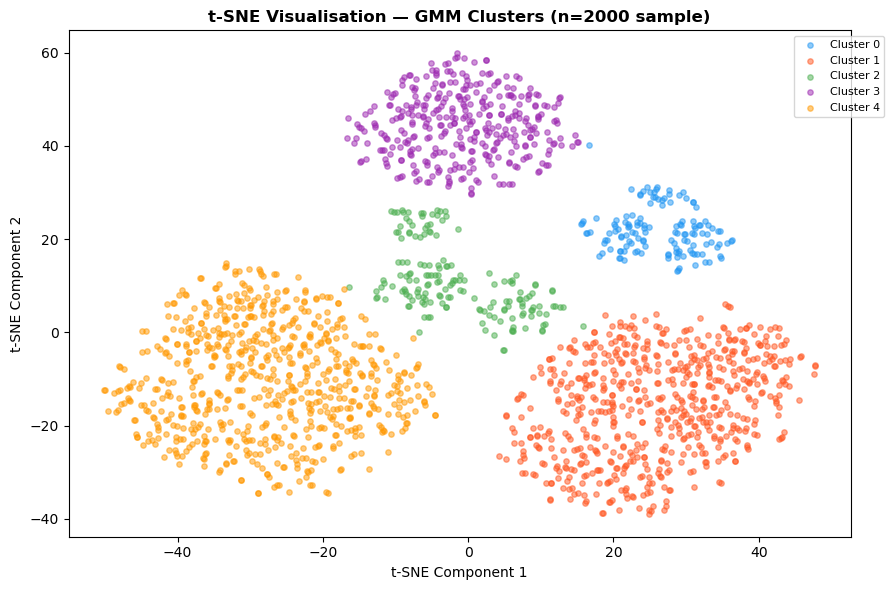

In [10]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=2000, replace=False)
X_sample = X_array[sample_idx]
labels_sample = cluster_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
for cluster_id in sorted(np.unique(labels_sample)):
    mask = labels_sample == cluster_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=f'Cluster {cluster_id}',
                alpha=0.5, s=15,
                color=palette[cluster_id])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title(f't-SNE Visualisation — GMM Clusters (n=2000 sample)',
          fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('plots/gmm_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

CLUSTER PROFILES
Cluster                    0      1      2      3      4
Hours_Studied          19.87  20.10  19.78  19.82  20.02
Attendance             80.72  79.79  79.23  79.70  80.36
Previous_Scores        74.85  74.81  75.38  75.14  75.25
Exam_Score             66.54  67.82  66.37  66.68  67.36
Tutoring_Sessions       1.54   1.47   1.54   1.51   1.49
Sleep_Hours             6.97   7.02   7.11   7.03   7.03
Physical_Activity       3.01   2.95   3.00   2.98   2.96
Motivation_Level        0.86   0.90   0.91   0.90   0.92
Access_to_Resources     1.13   1.10   1.09   1.09   1.09
Parental_Involvement    1.06   1.10   1.10   1.06   1.09
Family_Income           0.78   0.80   0.82   0.76   0.78
Learning_Disabilities   0.10   0.00   1.00   0.00   0.00


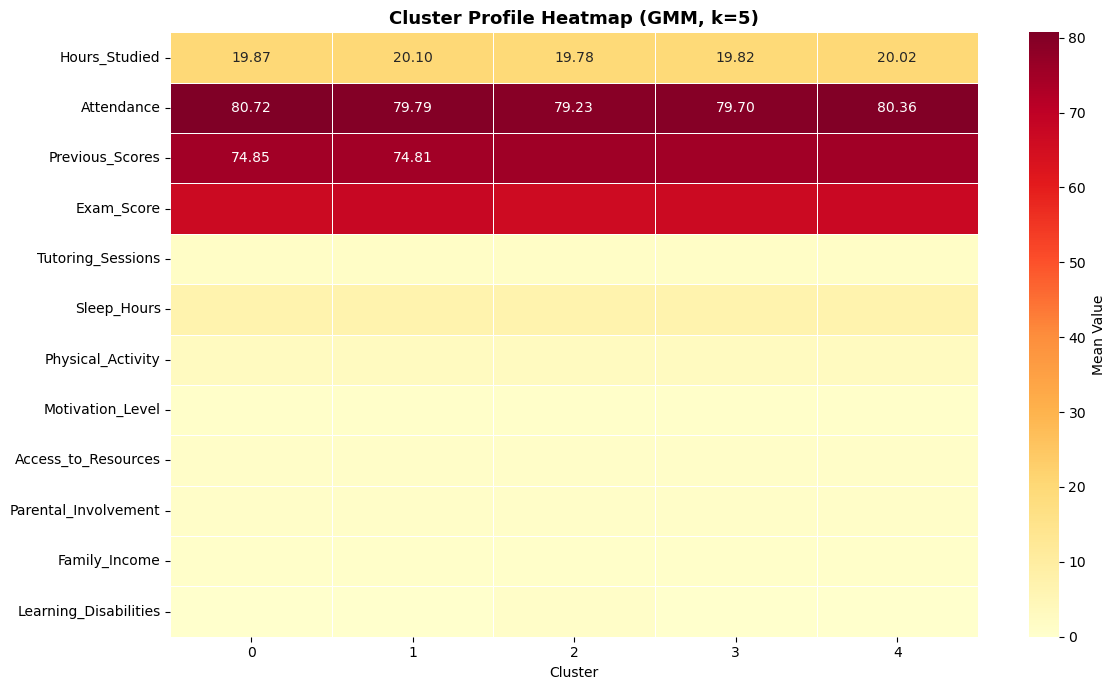


LEARNING DISABILITIES PER CLUSTER
Cluster
0    0.098
1    0.000
2    1.000
3    0.000
4    0.000
Name: Learning_Disabilities, dtype: float64
Cluster
0     499
1    2180
2     646
3    1138
4    2144
dtype: int64


In [11]:
df_encoded['Cluster'] = cluster_labels

profile_cols = [
    'Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score',
    'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity',
    'Motivation_Level', 'Access_to_Resources', 'Parental_Involvement',
    'Family_Income', 'Learning_Disabilities'
]

profile = df_encoded.groupby('Cluster')[profile_cols].mean().round(2)
print("CLUSTER PROFILES")
print(profile.T)

# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(profile.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title(f'Cluster Profile Heatmap (GMM, k={OPTIMAL_K})',
          fontweight='bold', fontsize=13)
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('plots/gmm_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Check Learning Disabilities per cluster
print("\nLEARNING DISABILITIES PER CLUSTER")
print(df_encoded.groupby('Cluster')['Learning_Disabilities'].mean().round(3))
print(df_encoded.groupby('Cluster').size())

In [12]:
from scipy import stats

# One-way ANOVA - tests if exam score differs significantly across clusters
groups = [df_encoded[df_encoded['Cluster'] == k]['Exam_Score'].values 
          for k in sorted(df_encoded['Cluster'].unique())]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA TEST — Exam Score across Clusters")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("Clusters show statistically significant differences in Exam Score (p < 0.05)")
    print("  This validates that discovered clusters are meaningfully distinct")
else:
    print("No statistically significant difference in Exam Score across clusters")

ANOVA TEST — Exam Score across Clusters
F-statistic: 31.2562
P-value:     0.000000
Clusters show statistically significant differences in Exam Score (p < 0.05)
  This validates that discovered clusters are meaningfully distinct


In [13]:
cluster_names_gmm = {
    0: 'General Students A',
    1: 'General Students B',
    2: 'Students with Learning Disabilities',
    3: 'At-Risk Borderline Group',
    4: 'General Students C'
}

df_encoded['Cluster_Label'] = df_encoded['Cluster'].map(cluster_names_gmm)

print("Cluster label distribution:")
print(df_encoded['Cluster_Label'].value_counts())

print("\nMean Exam Score per Cluster:")
print(df_encoded.groupby('Cluster_Label')['Exam_Score'].mean().round(2).sort_values())

df_encoded.to_csv('data/gmm_labelled.csv', index=False)
print("\nLabelled dataset saved")

Cluster label distribution:
General Students B                     2180
General Students C                     2144
At-Risk Borderline Group               1138
Students with Learning Disabilities     646
General Students A                      499
Name: Cluster_Label, dtype: int64

Mean Exam Score per Cluster:
Cluster_Label
Students with Learning Disabilities    66.37
General Students A                     66.54
At-Risk Borderline Group               66.68
General Students C                     67.36
General Students B                     67.82
Name: Exam_Score, dtype: float64

Labelled dataset saved


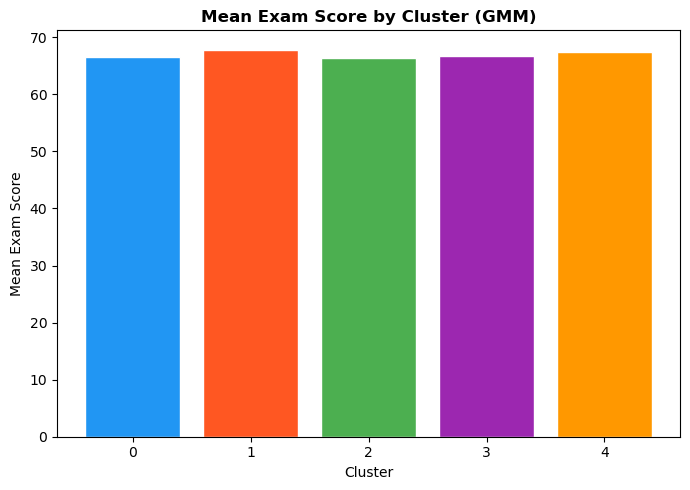

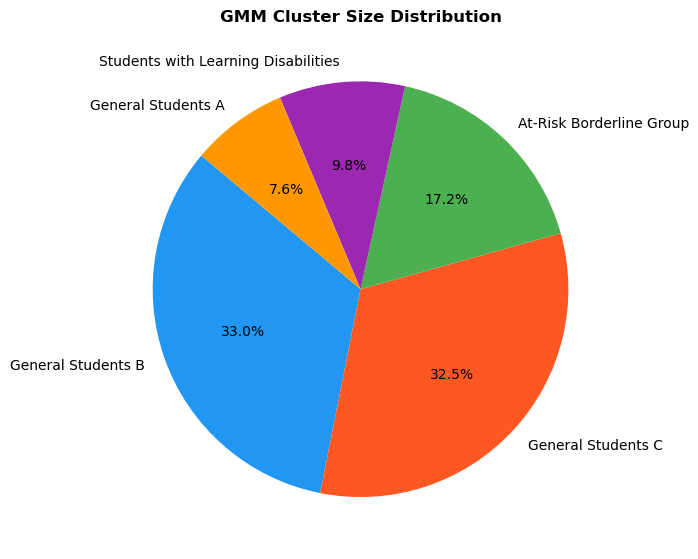

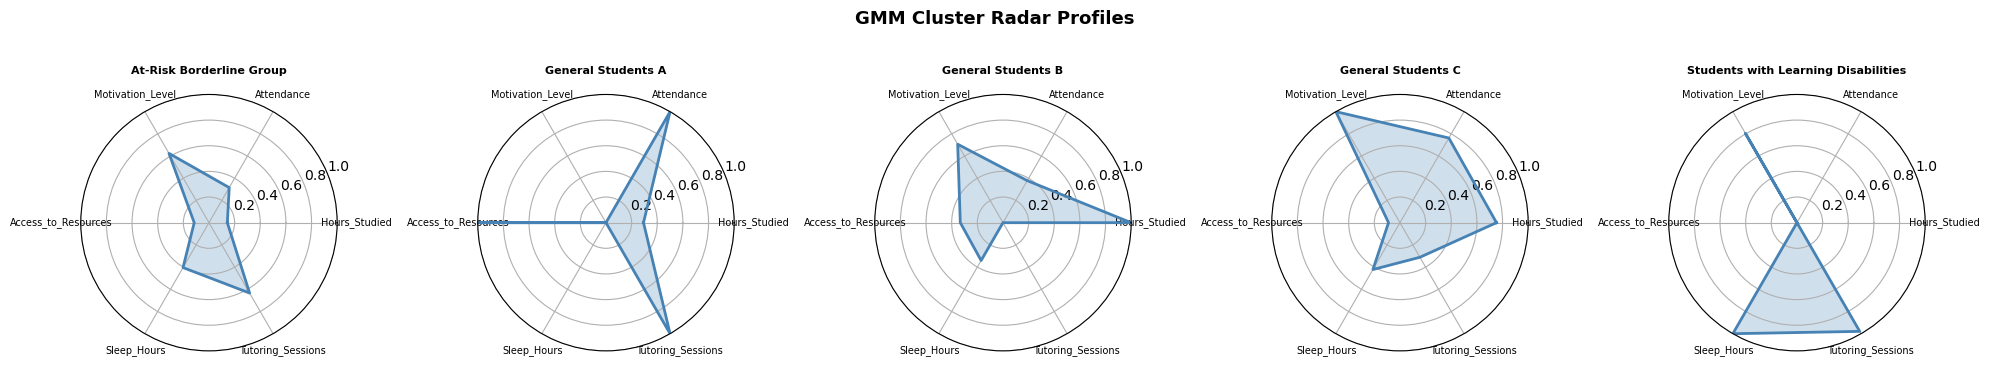

GMM missing plots saved


In [14]:
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

# exam by cluster
exam_by_cluster = df_encoded[df_encoded['Cluster'] != -1].groupby('Cluster')['Exam_Score'].mean()
plt.figure(figsize=(7, 5))
plt.bar(exam_by_cluster.index, exam_by_cluster.values,
        color=[palette[i % len(palette)] for i in exam_by_cluster.index], edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Mean Exam Score')
plt.title('Mean Exam Score by Cluster (GMM)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/gmm_exam_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# pie chart
sizes = df_encoded['Cluster_Label'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(sizes.values, labels=sizes.index, autopct='%1.1f%%',
        colors=palette[:len(sizes)], startangle=140)
plt.title('GMM Cluster Size Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/gmm_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

# radar
radar_cols = ['Hours_Studied', 'Attendance', 'Motivation_Level',
              'Access_to_Resources', 'Sleep_Hours', 'Tutoring_Sessions']
profile_radar = df_encoded[df_encoded['Cluster'] != -1].groupby('Cluster_Label')[radar_cols].mean()
profile_norm = (profile_radar - profile_radar.min()) / (profile_radar.max() - profile_radar.min())
angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw=dict(polar=True))
for ax, (label, row) in zip(axes, profile_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, color='steelblue')
    ax.fill(angles, values, alpha=0.25, color='steelblue')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_cols, size=7)
    ax.set_title(label, size=8, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)
plt.suptitle('GMM Cluster Radar Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/gmm_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("GMM missing plots saved")

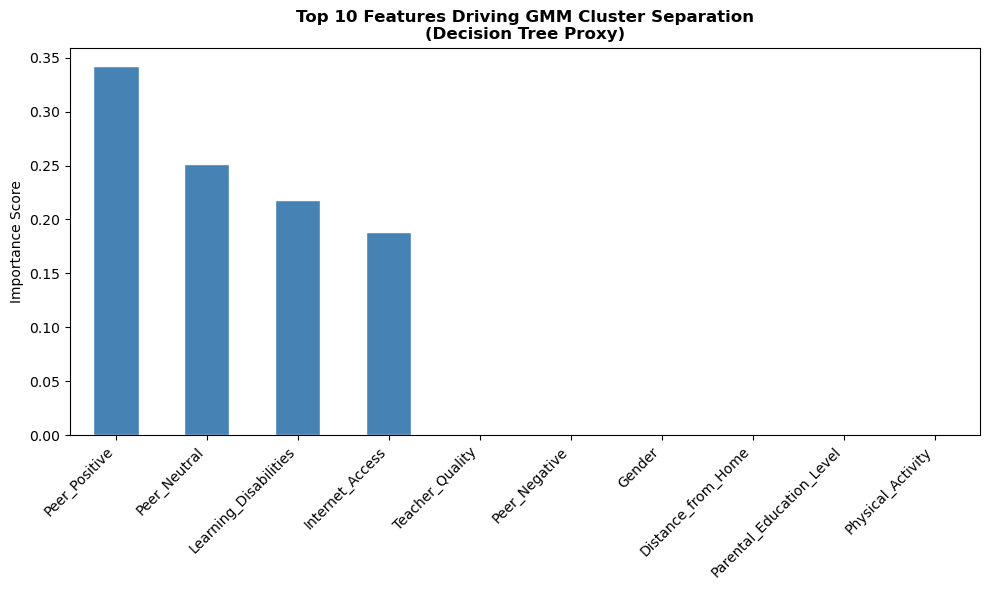

Top 5 most important features:
Peer_Positive            0.342180
Peer_Neutral             0.251165
Learning_Disabilities    0.218290
Internet_Access          0.188365
Teacher_Quality          0.000000
dtype: float64

Decision Tree reproduced 100.0% of GMM cluster assignments


In [15]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, cluster_labels)

importances = pd.Series(dt.feature_importances_,
                        index=X_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Features Driving GMM Cluster Separation\n(Decision Tree Proxy)',
          fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/gmm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importances.head())

importances.to_csv('data/gmm_feature_importance.csv', header=['Importance'])

# Check how well DT reproduced cluster assignments
dt_predictions = dt.predict(X_scaled)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(cluster_labels, dt_predictions)
print(f"\nDecision Tree reproduced {accuracy*100:.1f}% of GMM cluster assignments")

In [16]:
print("GMM CLUSTERING — FINAL SUMMARY")
print(f"Algorithm:         Gaussian Mixture Model")
print(f"Covariance Type:   {COV_TYPE}")
print(f"Optimal k:         {OPTIMAL_K}")
print(f"Silhouette Score:  {sil_final:.4f}")
print(f"Davies-Bouldin:    {db_final:.4f}")
print(f"Calinski-Harabasz: {ch_final:.1f}")
print(f"BIC:               {bic_final:.1f}")
print(f"AIC:               {aic_final:.1f}")
print(f"\nKey advantage: Soft probabilistic assignments")
print(f"Metrics saved: data/metrics_gmm.csv")

GMM CLUSTERING — FINAL SUMMARY
Algorithm:         Gaussian Mixture Model
Covariance Type:   full
Optimal k:         5
Silhouette Score:  0.1102
Davies-Bouldin:    2.4570
Calinski-Harabasz: 439.7
BIC:               -23892.2
AIC:               -32482.2

Key advantage: Soft probabilistic assignments
Metrics saved: data/metrics_gmm.csv


In [17]:
import pickle

with open('data/gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm_final, f)

print("GMM model saved")
print(f"Means shape: {gmm_final.means_.shape}")  # should be (5, 21)

GMM model saved
Means shape: (5, 21)
